### LeNet-5

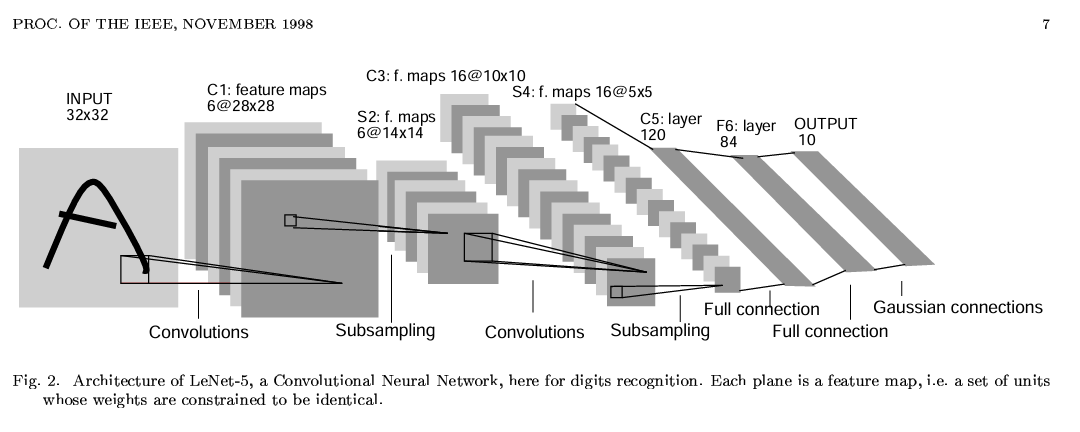

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets,transforms,models
import numpy as np
import matplotlib.pyplot as plt
import imageio
import time
import warnings
import random
import sys
import copy
import json
from PIL import Image
import os

In [16]:
class LeNet(nn.Module):
    def __init__(self) -> None:
        super(LeNet,self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 6, 5, 1, 0),  # Input: (1, 32, 32), Output: (6, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2)  # Output: (6, 14, 14)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(6, 16, 5, 1, 0),# Input: (6, 14, 14), Output: (16, 10, 10)
            nn.ReLU(),
            nn.MaxPool2d(2) # Output: (16, 5, 5)
        )
        self.out = nn.Sequential(
            nn.Linear(16*5*5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self,x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0),-1)
        out = self.out(x)

        return out

In [17]:
import pickle
import gzip

with gzip.open(("./dataset/mnist/mnist.pkl.gz"),'rb') as f:
    ((x_train, y_train),(x_valid, y_valid),(x_test,y_test))= pickle.load(f,encoding="latin-1")

(50000, 784)


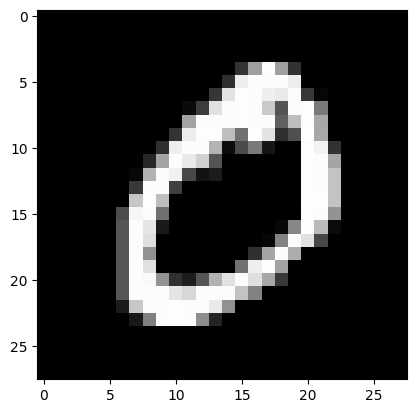

In [18]:
from matplotlib import pyplot as plt 
import numpy as np

plt.imshow(x_train[1].reshape((28,28)), cmap = "gray")
print(x_train.shape)

Original x_train shape: (50000, 784)
Resized x_train shape: (50000, 32, 32)
Original x_valid shape: (10000, 784)
Resized x_valid shape: (10000, 32, 32)


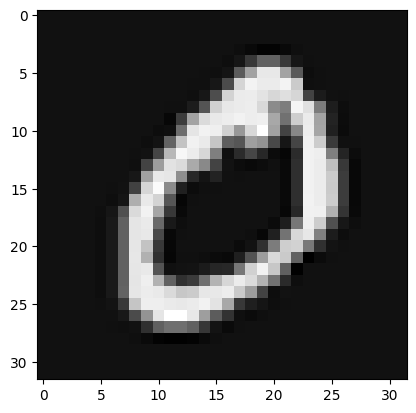

In [19]:
import gzip
import pickle
import numpy as np
from PIL import Image

# 加载 MNIST 数据集
with gzip.open("./dataset/mnist/mnist.pkl.gz", 'rb') as f:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

# 将数据从 numpy 数组转换为 PIL 图像并调整大小
def resize_images(images, size=(32, 32)):
    resized_images = []
    for image in images:
        # 从 numpy 数组创建 PIL 图像
        pil_image = Image.fromarray(image.reshape(28, 28))
        # 调整大小
        resized_image = pil_image.resize(size)
        # 转换回 numpy 数组并添加到列表中
        resized_images.append(np.array(resized_image))
    return np.array(resized_images)

# 扩展训练和验证数据集的图像
x_train_resized = resize_images(x_train)
x_valid_resized = resize_images(x_valid)

print(f"Original x_train shape: {x_train.shape}")
print(f"Resized x_train shape: {x_train_resized.shape}")
print(f"Original x_valid shape: {x_valid.shape}")
print(f"Resized x_valid shape: {x_valid_resized.shape}")
plt.imshow(x_train_resized[1], cmap = "gray")


In [ ]:
batch_size = 64 # 建议稍微调大 batch，16 有点太小，收敛不稳定

import torch
from torch.utils.data import TensorDataset, DataLoader

# --- 修改重点：添加归一化 (/ 255.0) ---
# 推荐写法：一次性完成转换、归一化和维度增加
x_train = torch.from_numpy(x_train_resized).float() / 255.0
x_valid = torch.from_numpy(x_valid_resized).float() / 255.0

# 增加通道维 [Batch, 1, 32, 32]
x_train = x_train.unsqueeze(1)
x_valid = x_valid.unsqueeze(1)

# 标签转换 (保持不变)
y_train = torch.tensor(y_train, dtype=torch.long)
y_valid = torch.tensor(y_valid, dtype=torch.long)

# 创建数据集和数据加载器
train_ds = TensorDataset(x_train, y_train)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

valid_ds = TensorDataset(x_valid, y_valid)
valid_dl = DataLoader(valid_ds, batch_size=batch_size * 2)

dataloaders = {
    'train': train_dl,
    'valid': valid_dl
}

In [21]:
train_on_GPU = torch.cuda.is_available()

if not train_on_GPU:
    print('CUDA is not available. Training on CPU...')
else:
    print('CUDA is available. Training on GPU...')

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

CUDA is available. Training on GPU...


In [22]:
model = LeNet()
model

LeNet(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [23]:
model = model.to(device)

params_to_update = model.parameters()

for name, param in model.named_parameters():  # 使用 named_parameters() 方法
        if param.requires_grad == True:
            print("\t", name)

	 conv1.0.weight
	 conv1.0.bias
	 conv2.0.weight
	 conv2.0.bias
	 out.0.weight
	 out.0.bias
	 out.2.weight
	 out.2.bias
	 out.4.weight
	 out.4.bias


In [ ]:
optimizer_ft = optim.Adam(params_to_update, lr = 1e-3)

scheduler = optim.lr_scheduler.StepLR(optimizer_ft,step_size=20, gamma=0.1) # 学习率每10个epoch衰减为原来的1/10

criterion = nn.CrossEntropyLoss()

In [25]:
import time
import copy
import torch

def train_model(model, dataloaders,criterion, optimizer_ft, scheduler, num_epochs=25, filename='Alexnet.pth'):
    since = time.time()
    best_acc = 0

    model.to(device)

    val_acc_history = []
    train_acc_history = []
    valid_losses = []
    train_losses = []
    test_losses = []
    LRs = [optimizer_ft.param_groups[0]['lr']]

    best_model_wts = copy.deepcopy(model.state_dict())  # 最好模型权重文件

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs-1))
        print('-'*10)

        # 训练和验证
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # 训练模式
                
            else:
                model.eval()  # 验证模式

            running_loss = 0.0
            running_corrects = 0.0

            # 遍历数据
            for xb, yb in dataloaders[phase]:
                # print(xb.shape)
                xb= xb.to(device)
                yb = yb.to(device)

                # 梯度清零
                optimizer_ft.zero_grad()

                # 只有训练的时候计算和更新梯度
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(xb)
                    loss = criterion(outputs, yb)

                    _, preds = torch.max(outputs, 1)

                    # 训练阶段更新权重
                    if phase == 'train':
                        loss.backward()
                        optimizer_ft.step()

                # 计算损失
                running_loss += loss.item() * xb.size(0)
                running_corrects += torch.sum(preds == yb.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # 保存最佳模型
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                # state = {
                #     'state_dict': model.state_dict(),
                #     'best_acc': best_acc,
                #     'optimizer': optimizer_ft.state_dict(),
                #     'scheduler': scheduler.state_dict(),
                #     'epoch': epoch
                # }
                torch.save(best_model_wts, filename)
            
            if phase == 'valid':
                val_acc_history.append(epoch_acc)
                valid_losses.append(epoch_loss)
                scheduler.step(epoch_loss)
            
            if phase == 'train':
                train_acc_history.append(epoch_acc)
                train_losses.append(epoch_loss)

        print('Optimizer learning rate: {:.7f}'.format(optimizer_ft.param_groups[0]['lr']))
        LRs.append(optimizer_ft.param_groups[0]['lr'])
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # 训练完后用最好的一次作为最终结果
    model.load_state_dict(best_model_wts)
    return model, val_acc_history, train_acc_history, valid_losses, train_losses, LRs


In [ ]:
model_ft, val_acc_history, train_acc_history, valid_losses, train_losses, LRs = train_model(
    model, 
    dataloaders, 
    criterion, 
    optimizer_ft, 
    scheduler,  # <- 确保传递 scheduler 参数
    num_epochs=80,
    filename='LeNet-5.pth'
)

Epoch 0/299
----------
train Loss: 2.3028 Acc: 0.1136
valid Loss: 2.3038 Acc: 0.1064
Optimizer learning rate: 0.0001000

Epoch 1/299
----------
train Loss: 2.3027 Acc: 0.1136
valid Loss: 2.3038 Acc: 0.1064
Optimizer learning rate: 0.0001000

Epoch 2/299
----------
train Loss: 2.3027 Acc: 0.1136
valid Loss: 2.3038 Acc: 0.1064
Optimizer learning rate: 0.0001000

Epoch 3/299
----------
train Loss: 2.3026 Acc: 0.1136
valid Loss: 2.3037 Acc: 0.1064
Optimizer learning rate: 0.0001000

Epoch 4/299
----------
train Loss: 2.3026 Acc: 0.1136
valid Loss: 2.3037 Acc: 0.1064
Optimizer learning rate: 0.0001000

Epoch 5/299
----------
train Loss: 2.3026 Acc: 0.1136
valid Loss: 2.3036 Acc: 0.1064
Optimizer learning rate: 0.0001000

Epoch 6/299
----------
train Loss: 2.3025 Acc: 0.1136
valid Loss: 2.3036 Acc: 0.1064
Optimizer learning rate: 0.0001000

Epoch 7/299
----------
train Loss: 2.3025 Acc: 0.1136
valid Loss: 2.3036 Acc: 0.1064
Optimizer learning rate: 0.0001000

Epoch 8/299
----------
train Los

模型权重加载成功！
验证完成！在测试集上的准确率为: 11.35%


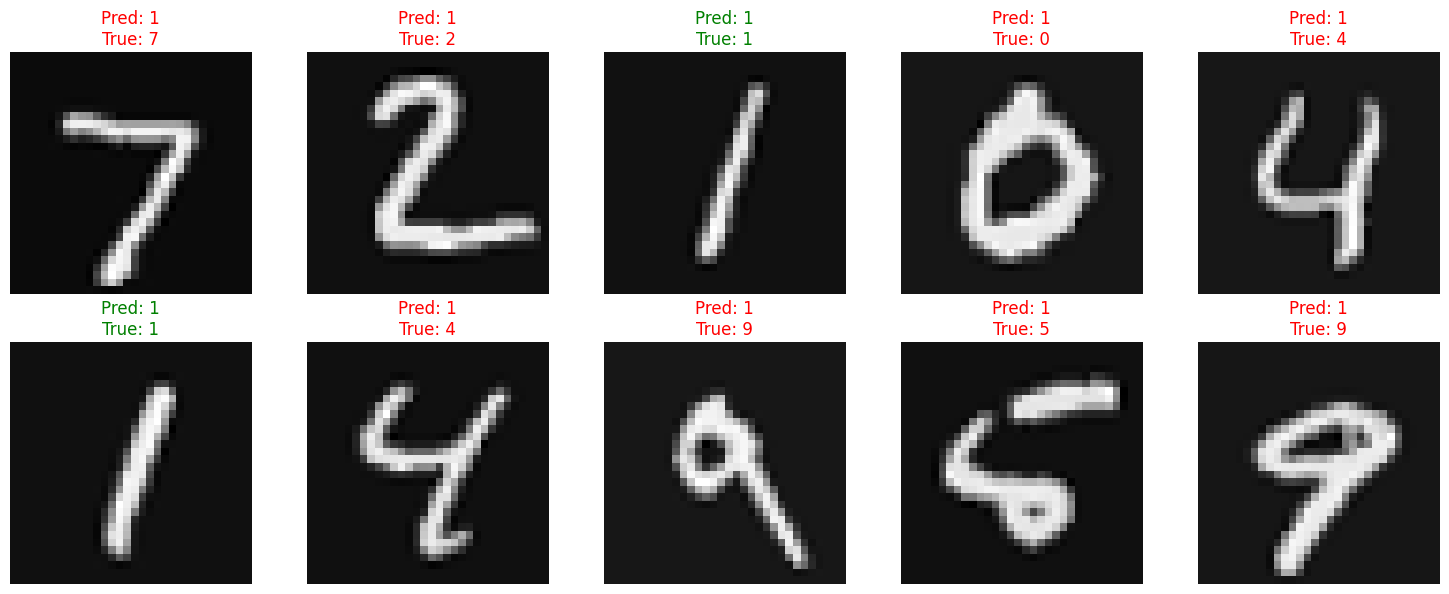

In [30]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. 数据预处理函数（确保测试集也被 resize 到 32x32）
def preprocess_test_data(x_test, y_test):
    resized_images = []
    for image in x_test:
        # 假设原始数据是 784 维向量，转为 28x28
        pil_image = Image.fromarray(image.reshape(28, 28))
        # Resize 为 LeNet-5 要求的 32x32
        resized_image = pil_image.resize((32, 32))
        resized_images.append(np.array(resized_image))
    
    # 转换为 Tensor: [N, C, H, W]，MNIST 是单通道，所以 C=1
    x_tensor = torch.tensor(np.array(resized_images)).float().unsqueeze(1)
    y_tensor = torch.tensor(y_test).long()
    
    # 如果像素值是 0-255，归一化到 0-1
    if x_tensor.max() > 1:
        x_tensor /= 255.0
        
    return TensorDataset(x_tensor, y_tensor)

# 2. 准备测试数据加载器
# 假设你已经通过 pickle 加载了 x_test, y_test
test_dataset = preprocess_test_data(x_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 3. 改进后的测试与可视化函数
def test_and_visualize(model, test_loader, device, num_images=10):
    model.to(device)
    model.eval()
    
    correct = 0
    total = 0
    
    display_images = []
    display_labels = []
    display_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # 收集前 num_images 张图片用于展示
            if len(display_images) < num_images:
                # 遍历 batch 中的每一张图
                for i in range(images.size(0)):
                    if len(display_images) < num_images:
                        display_images.append(images[i].cpu())
                        display_labels.append(labels[i].cpu())
                        display_preds.append(predicted[i].cpu())
                    else:
                        break

    print(f"验证完成！在测试集上的准确率为: {100 * correct / total:.2f}%")

    # 展示结果
    plt.figure(figsize=(15, 6))
    for i in range(num_images):
        plt.subplot(2, 5, i + 1)
        img = display_images[i].squeeze() # 移除通道维 (1, 32, 32) -> (32, 32)
        plt.imshow(img, cmap='gray')
        
        is_correct = display_preds[i] == display_labels[i]
        color = 'green' if is_correct else 'red'
        
        plt.title(f"Pred: {display_preds[i].item()}\nTrue: {display_labels[i].item()}", color=color)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 4. 执行验证
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 注意：请确保 model 已经定义（例如 model = LeNet5()）
try:
    model.load_state_dict(torch.load('LeNet-5.pth', map_location=device))
    print("模型权重加载成功！")
    test_and_visualize(model, test_dataloader, device)
except FileNotFoundError:
    print("错误：找不到 'LeNet-5.pth' 文件，请确认模型已保存。")